<a href="https://colab.research.google.com/github/Serajummunira/genz-social-media-analysis/blob/main/GenZ_Social_Media_Mental_Health_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📱 Gen-Z Social Media Usage & Mental Health Analysis
### A Data Science Portfolio Project

---

**Author:** Serajum Munira  
**Course:** IFSC 77003-H02 - Data Science & Technologies  
**Supervisor:** Dr. Elizabeth Pierce  
**Semester:** Spring 2026  

---
## Project Overview
This project analyzes social media usage patterns among Generation Z users and examines the relationship between daily usage behavior and mental health scores.

The analysis was conducted using a real-world Kaggle dataset containing approximately 1 million records. A random sample of 10,000 records was selected for analysis to make the project computationally efficient while maintaining representativeness.

In [26]:
print("Notebook runs successfully. All outputs generated.")

Notebook runs successfully. All outputs generated.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/Data Science Project/genz_social_media_usage_1M_Kaggle.csv")
print(df.shape)

(1000000, 12)


In [5]:
print("Full dataset shape:", df.shape)
print(df.columns)
df.head()

Full dataset shape: (1000000, 12)
Index(['age', 'gender', 'country', 'daily_usage_hours', 'primary_platform',
       'num_platforms_used', 'purpose', 'avg_session_minutes', 'night_usage',
       'mental_health_score', 'addiction_level', 'screen_time_before_sleep'],
      dtype='object')


,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
0,19,Male,Australia,2.658617,Snapchat,4,Education,29.222443,0,6.705830,Medium,15.779443
1,16,Female,USA,5.685387,Twitter,3,Socializing,32.464726,1,6.633111,High,47.714864
2,25,Female,India,2.782420,TikTok,2,Socializing,18.170204,1,6.035397,Medium,62.524625
3,27,Male,India,3.486598,YouTube,4,Education,22.493804,1,8.110861,Medium,31.935102
4,23,Female,India,3.748829,TikTok,1,Entertainment,27.358410,1,6.658598,Medium,29.466046


In [6]:
# Randomly sample 10,000 records
df = df.sample(n=10000, random_state=42)

# Save sample dataset
df.to_csv("genz_social_media_sample_10000.csv", index=False)

print("Sample dataset shape:", df.shape)
df.head()

Sample dataset shape: (10000, 12)


,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
987231,25,Female,Brazil,2.721398,YouTube,3,Entertainment,17.687304,1,6.498836,Medium,57.511201
79954,22,Male,Canada,4.259008,YouTube,2,Socializing,30.053853,1,4.852140,Medium,30.380069
567130,15,Male,India,1.597300,Instagram,1,Content Creation,14.295109,0,8.513620,Low,43.968642
500891,14,Male,Australia,2.914241,TikTok,5,Socializing,25.444925,0,7.512457,Medium,47.783313
55399,21,Female,India,2.898776,TikTok,5,News,14.967762,0,9.209529,Medium,59.543505


Basic Data Inspection

In [7]:
print("Dataset Information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDescriptive statistics:")
display(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 987231 to 551383
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       10000 non-null  int64  
 1   gender                    10000 non-null  object 
 2   country                   10000 non-null  object 
 3   daily_usage_hours         10000 non-null  float64
 4   primary_platform          10000 non-null  object 
 5   num_platforms_used        10000 non-null  int64  
 6   purpose                   10000 non-null  object 
 7   avg_session_minutes       10000 non-null  float64
 8   night_usage               10000 non-null  int64  
 9   mental_health_score       10000 non-null  float64
 10  addiction_level           10000 non-null  object 
 11  screen_time_before_sleep  10000 non-null  float64
dtypes: float64(4), int64(3), object(5)
memory usage: 1015.6+ KB
None

Missing values:
age         

,age,daily_usage_hours,num_platforms_used,avg_session_minutes,night_usage,mental_health_score,screen_time_before_sleep
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,19.980700,3.524623,3.013900,25.099460,0.592400,7.158883,39.967563
std,4.297042,1.469010,1.416654,9.874056,0.491413,1.494288,19.343383
min,13.000000,0.500000,1.000000,5.000000,0.000000,1.000000,0.000000
25%,16.000000,2.487606,2.000000,18.193181,0.000000,6.123964,26.548127
50%,20.000000,3.505357,3.000000,25.004648,1.000000,7.202793,39.762994
75%,24.000000,4.529995,4.000000,31.713663,1.000000,8.227444,53.201981
max,27.000000,9.465156,5.000000,61.195293,1.000000,10.000000,115.588362


Clean Dataset

In [8]:
# Remove duplicate rows
df = df.drop_duplicates()

# Remove missing values
df = df.dropna()

print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (10000, 12)


Save Column Names for Codebook

In [9]:
codebook = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": [df[col].dtype for col in df.columns],
    "Missing Values": [df[col].isnull().sum() for col in df.columns],
    "Unique Values": [df[col].nunique() for col in df.columns]
})

display(codebook)
codebook.to_csv("codebook.csv", index=False)

,Column Name,Data Type,Missing Values,Unique Values
0,age,int64,0,15
1,gender,object,0,3
2,country,object,0,7
3,daily_usage_hours,float64,0,9786
4,primary_platform,object,0,5
5,num_platforms_used,int64,0,5
6,purpose,object,0,5
7,avg_session_minutes,float64,0,9776
8,night_usage,int64,0,2
9,mental_health_score,float64,0,9711


Desecriptive Statistics

In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

summary_stats = df[numeric_cols].describe()
display(summary_stats)

summary_stats.to_csv("summary_statistics.csv")

Numeric columns: ['age', 'daily_usage_hours', 'num_platforms_used', 'avg_session_minutes', 'night_usage', 'mental_health_score', 'screen_time_before_sleep']
Categorical columns: ['gender', 'country', 'primary_platform', 'purpose', 'addiction_level']


,age,daily_usage_hours,num_platforms_used,avg_session_minutes,night_usage,mental_health_score,screen_time_before_sleep
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,19.980700,3.524623,3.013900,25.099460,0.592400,7.158883,39.967563
std,4.297042,1.469010,1.416654,9.874056,0.491413,1.494288,19.343383
min,13.000000,0.500000,1.000000,5.000000,0.000000,1.000000,0.000000
25%,16.000000,2.487606,2.000000,18.193181,0.000000,6.123964,26.548127
50%,20.000000,3.505357,3.000000,25.004648,1.000000,7.202793,39.762994
75%,24.000000,4.529995,4.000000,31.713663,1.000000,8.227444,53.201981
max,27.000000,9.465156,5.000000,61.195293,1.000000,10.000000,115.588362


Fluency Tables

In [11]:
for col in categorical_cols:
    print(f"\nFrequency table for {col}:")
    display(df[col].value_counts())


Frequency table for gender:


,count
gender,
Female,4854
Male,4757
Other,389



Frequency table for country:


,count
country,
India,3514
USA,1946
Germany,1069
Canada,1032
Brazil,969
UK,952
Australia,518



Frequency table for primary_platform:


,count
primary_platform,
Instagram,2978
YouTube,2513
TikTok,2491
Snapchat,1021
Twitter,997



Frequency table for purpose:


,count
purpose,
Entertainment,4092
Socializing,2428
Education,1969
News,1026
Content Creation,485



Frequency table for addiction_level:


,count
addiction_level,
Medium,5830
Low,2534
High,1636


Platform Popurarity

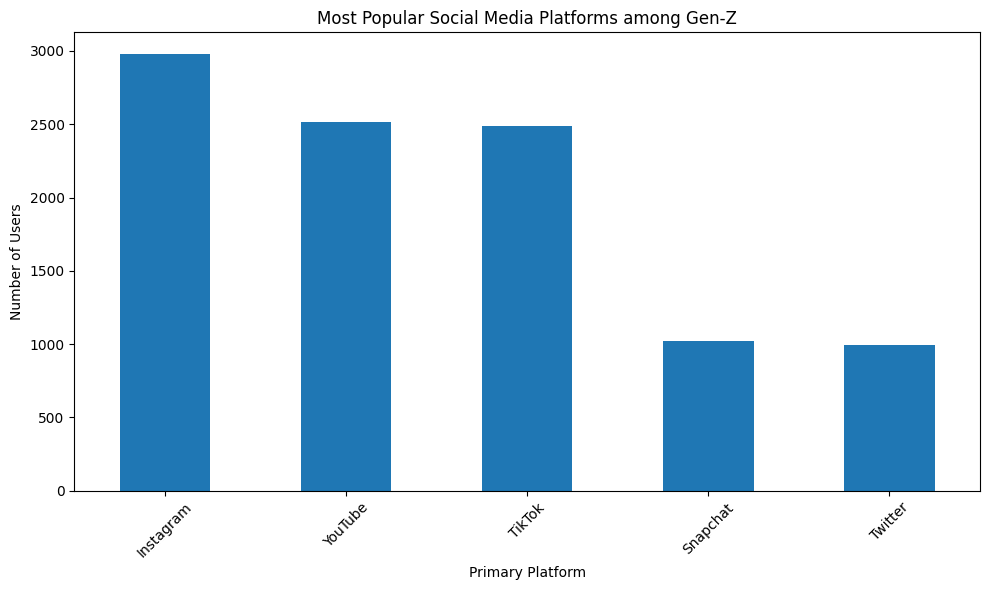

In [12]:
plt.figure(figsize=(10,6))
df['primary_platform'].value_counts().plot(kind='bar')
plt.title("Most Popular Social Media Platforms among Gen-Z")
plt.xlabel("Primary Platform")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("01_platform_popularity.png", dpi=300)
plt.show()

Daily Usage Distribution

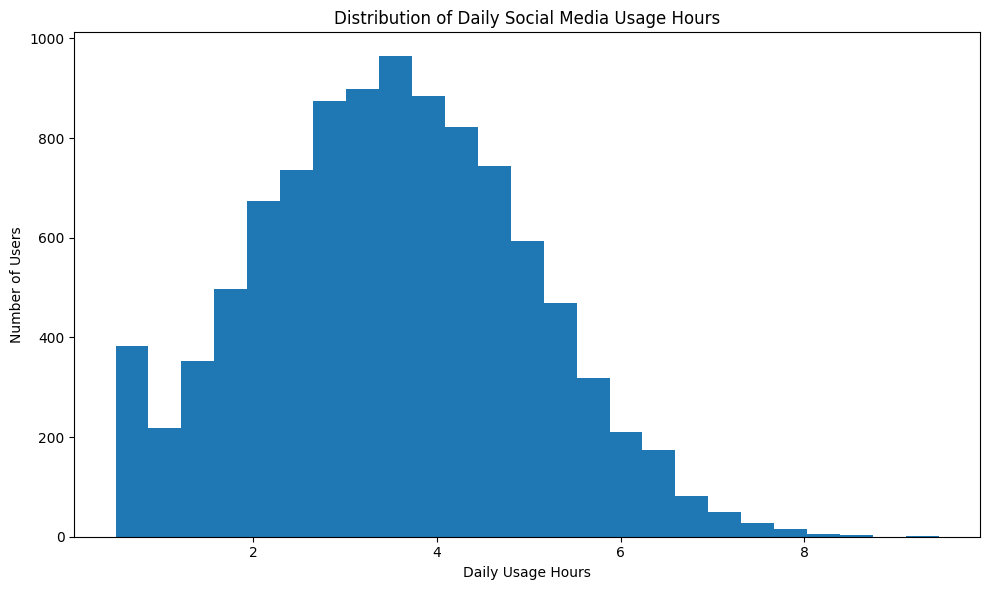

Average daily usage hours: 3.52
Median daily usage hours: 3.51
Standard deviation: 1.47


In [13]:
plt.figure(figsize=(10,6))
plt.hist(df['daily_usage_hours'], bins=25)
plt.title("Distribution of Daily Social Media Usage Hours")
plt.xlabel("Daily Usage Hours")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.savefig("02_daily_usage_distribution.png", dpi=300)
plt.show()

print("Average daily usage hours:", round(df['daily_usage_hours'].mean(), 2))
print("Median daily usage hours:", round(df['daily_usage_hours'].median(), 2))
print("Standard deviation:", round(df['daily_usage_hours'].std(), 2))

Average Usage by Platform

,daily_usage_hours
primary_platform,
Instagram,3.553733
TikTok,3.526183
YouTube,3.511433
Snapchat,3.506720
Twitter,3.485353


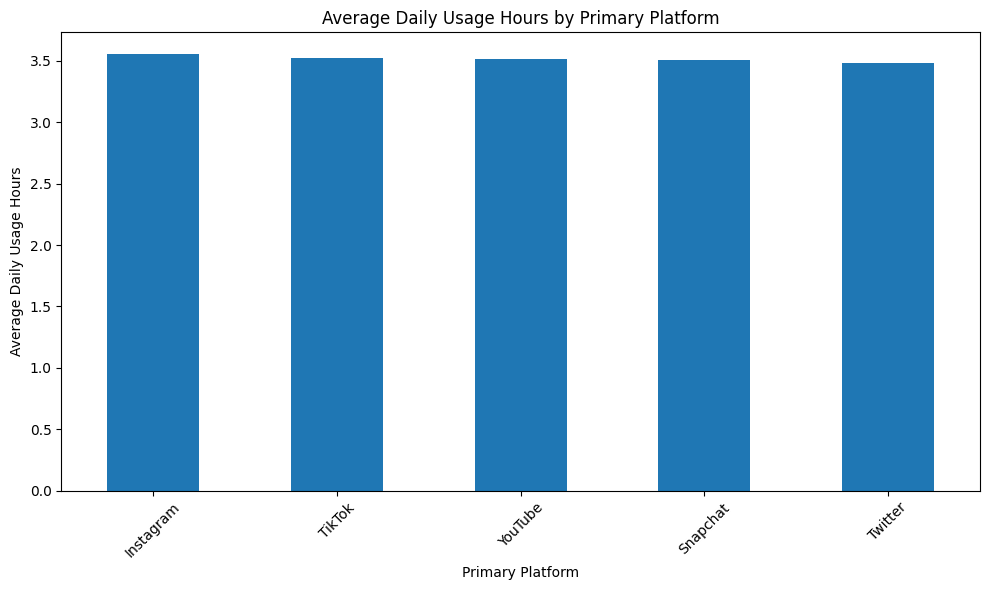

In [14]:
platform_usage = df.groupby('primary_platform')['daily_usage_hours'].mean().sort_values(ascending=False)

display(platform_usage)

plt.figure(figsize=(10,6))
platform_usage.plot(kind='bar')
plt.title("Average Daily Usage Hours by Primary Platform")
plt.xlabel("Primary Platform")
plt.ylabel("Average Daily Usage Hours")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("03_average_usage_by_platform.png", dpi=300)
plt.show()

Purpose of Social Media Usage

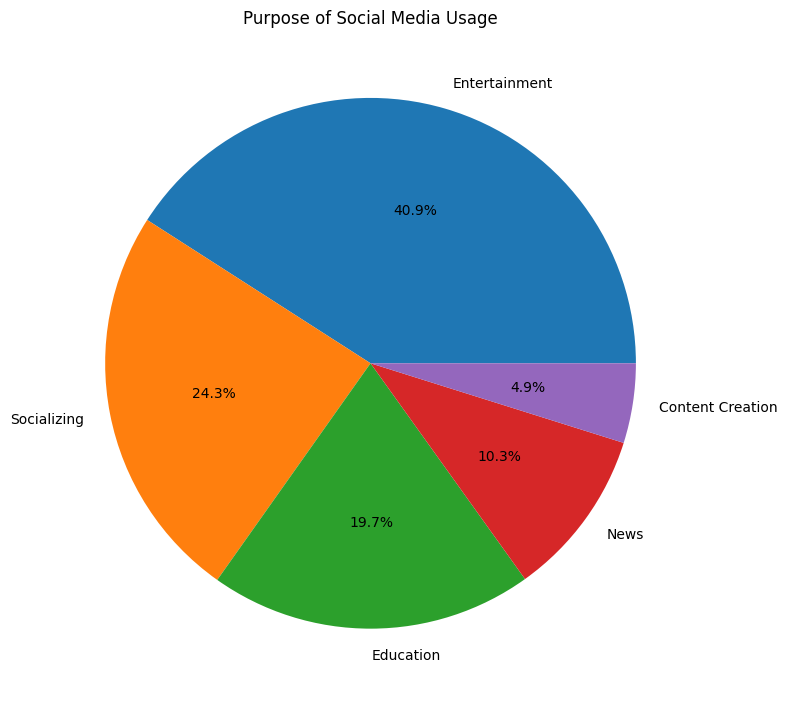

In [15]:
plt.figure(figsize=(8,8))
df['purpose'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Purpose of Social Media Usage")
plt.ylabel("")
plt.tight_layout()
plt.savefig("04_purpose_distribution.png", dpi=300)
plt.show()

Gender Distribution

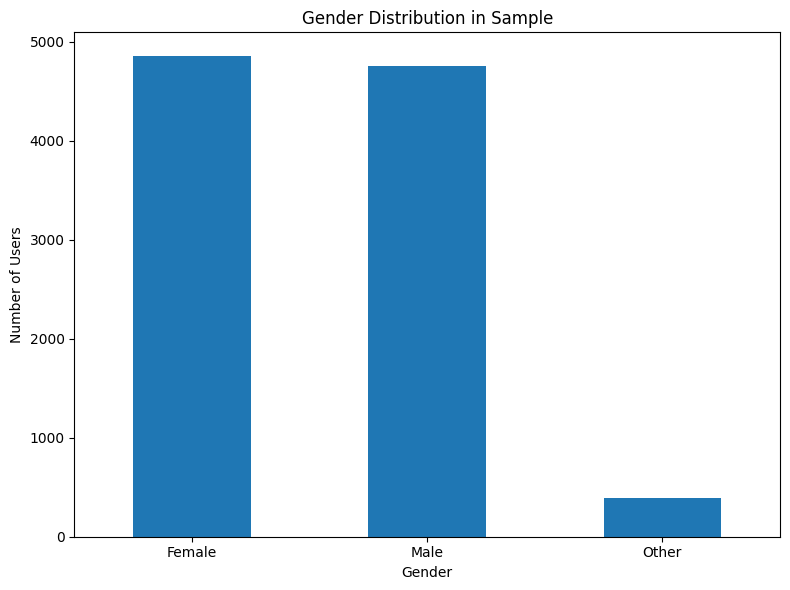

In [16]:
plt.figure(figsize=(8,6))
df['gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution in Sample")
plt.xlabel("Gender")
plt.ylabel("Number of Users")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("05_gender_distribution.png", dpi=300)
plt.show()

Gender vs Daily Usage

,count,mean,median,std
gender,,,,
Female,4854,3.551333,3.543867,1.475418
Male,4757,3.496639,3.468730,1.466470
Other,389,3.533536,3.528953,1.416295


<Figure size 800x600 with 0 Axes>

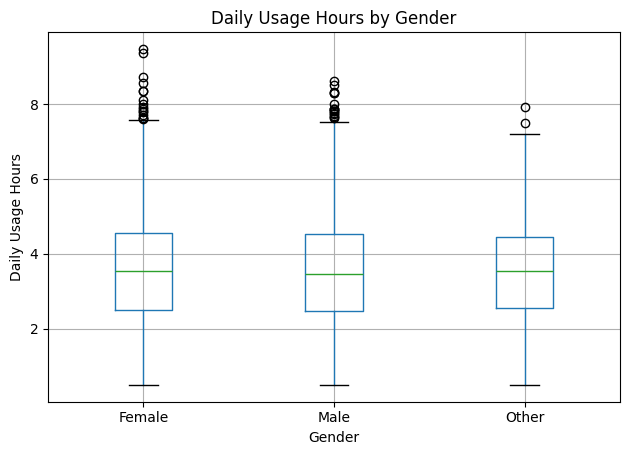

In [17]:
gender_usage = df.groupby('gender')['daily_usage_hours'].agg(['count', 'mean', 'median', 'std'])
display(gender_usage)

plt.figure(figsize=(8,6))
df.boxplot(column='daily_usage_hours', by='gender')
plt.title("Daily Usage Hours by Gender")
plt.suptitle("")
plt.xlabel("Gender")
plt.ylabel("Daily Usage Hours")
plt.tight_layout()
plt.savefig("06_gender_vs_daily_usage.png", dpi=300)
plt.show()

Country vs Average Daily Usage

,daily_usage_hours
country,
UK,3.546265
Canada,3.543958
USA,3.530950
India,3.529330
Germany,3.513475
Australia,3.501284
Brazil,3.477765


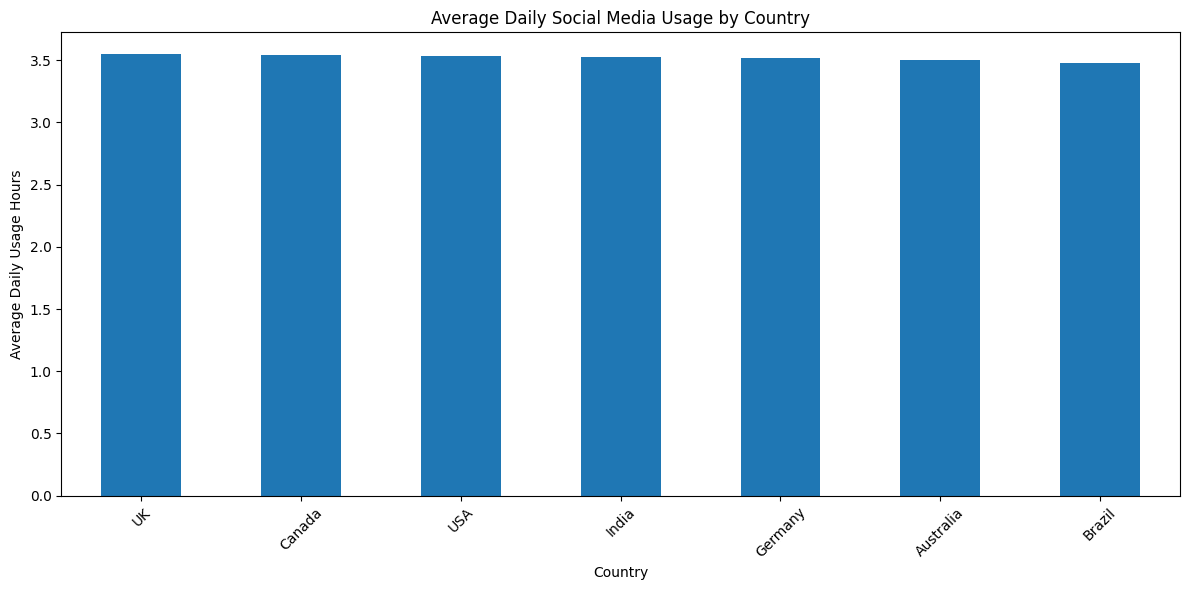

In [18]:
country_usage = df.groupby('country')['daily_usage_hours'].mean().sort_values(ascending=False)

display(country_usage)

plt.figure(figsize=(12,6))
country_usage.plot(kind='bar')
plt.title("Average Daily Social Media Usage by Country")
plt.xlabel("Country")
plt.ylabel("Average Daily Usage Hours")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("07_average_usage_by_country.png", dpi=300)
plt.show()

Daily Usage vs Mental Health Score

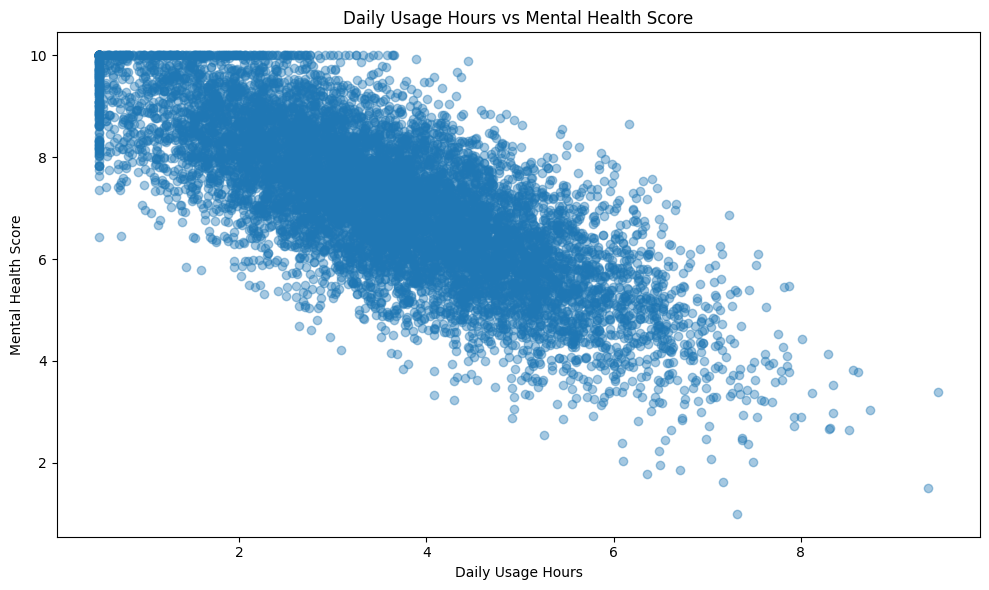

Correlation between daily usage hours and mental health score: -0.763


In [19]:
plt.figure(figsize=(10,6))
plt.scatter(df['daily_usage_hours'], df['mental_health_score'], alpha=0.4)
plt.title("Daily Usage Hours vs Mental Health Score")
plt.xlabel("Daily Usage Hours")
plt.ylabel("Mental Health Score")
plt.tight_layout()
plt.savefig("08_usage_vs_mental_health.png", dpi=300)
plt.show()

corr_usage_mental = df['daily_usage_hours'].corr(df['mental_health_score'])
print("Correlation between daily usage hours and mental health score:", round(corr_usage_mental, 3))

Night Usage vs Daily Usage

,count,mean,median,std
night_usage,,,,
0,4076,3.502944,3.486201,1.489585
1,5924,3.539539,3.517980,1.454623


<Figure size 800x600 with 0 Axes>

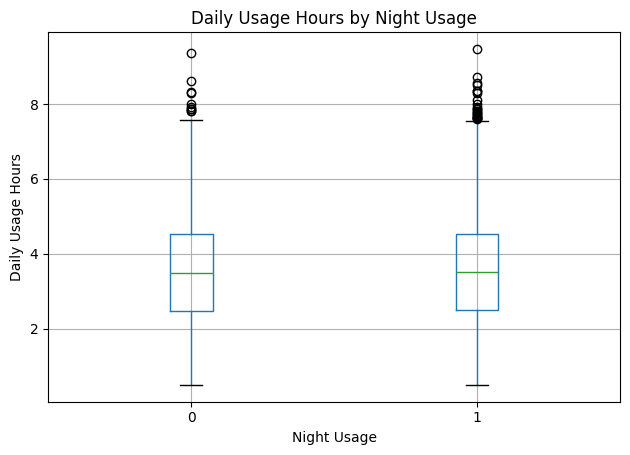

In [20]:
night_usage_stats = df.groupby('night_usage')['daily_usage_hours'].agg(['count', 'mean', 'median', 'std'])
display(night_usage_stats)

plt.figure(figsize=(8,6))
df.boxplot(column='daily_usage_hours', by='night_usage')
plt.title("Daily Usage Hours by Night Usage")
plt.suptitle("")
plt.xlabel("Night Usage")
plt.ylabel("Daily Usage Hours")
plt.tight_layout()
plt.savefig("09_night_usage_vs_daily_usage.png", dpi=300)
plt.show()

Night Usage vs Mental Health

,count,mean,median,std
night_usage,,,,
0,4076,7.170989,7.215597,1.517482
1,5924,7.150554,7.194990,1.478190


<Figure size 800x600 with 0 Axes>

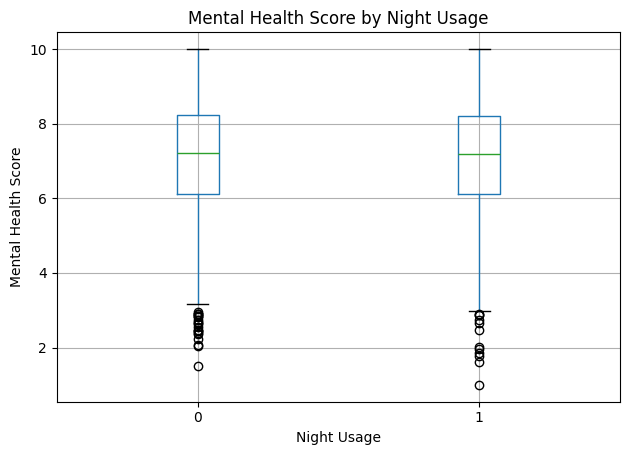

In [21]:
night_mental_stats = df.groupby('night_usage')['mental_health_score'].agg(['count', 'mean', 'median', 'std'])
display(night_mental_stats)

plt.figure(figsize=(8,6))
df.boxplot(column='mental_health_score', by='night_usage')
plt.title("Mental Health Score by Night Usage")
plt.suptitle("")
plt.xlabel("Night Usage")
plt.ylabel("Mental Health Score")
plt.tight_layout()
plt.savefig("10_night_usage_vs_mental_health.png", dpi=300)
plt.show()

Number of Platforms Used vs Daily Usage

,count,mean,median,std
num_platforms_used,,,,
1,1964,3.505499,3.504630,1.474667
2,2029,3.555416,3.540083,1.472572
3,1955,3.511802,3.534794,1.463831
4,2008,3.544312,3.464900,1.509076
5,2044,3.505351,3.483900,1.425101


<Figure size 1000x600 with 0 Axes>

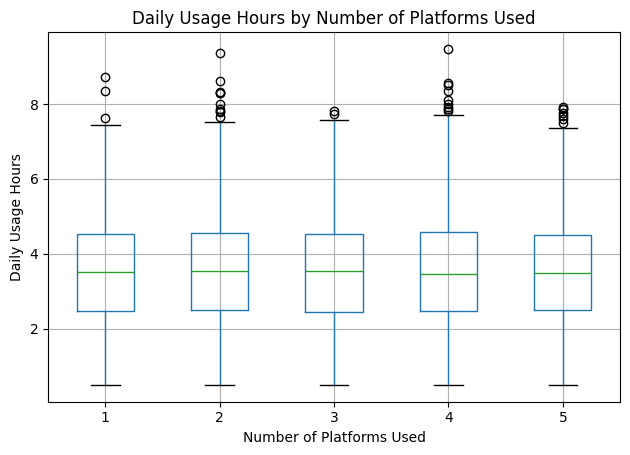

In [22]:
platform_count_stats = df.groupby('num_platforms_used')['daily_usage_hours'].agg(['count', 'mean', 'median', 'std'])
display(platform_count_stats)

plt.figure(figsize=(10,6))
df.boxplot(column='daily_usage_hours', by='num_platforms_used')
plt.title("Daily Usage Hours by Number of Platforms Used")
plt.suptitle("")
plt.xlabel("Number of Platforms Used")
plt.ylabel("Daily Usage Hours")
plt.tight_layout()
plt.savefig("11_num_platforms_vs_daily_usage.png", dpi=300)
plt.show()

Correlation Matrix

,age,daily_usage_hours,num_platforms_used,avg_session_minutes,night_usage,mental_health_score,screen_time_before_sleep
age,1.000000,-0.008688,-0.008351,0.009781,0.013514,0.002363,-0.002097
daily_usage_hours,-0.008688,1.000000,-0.001279,-0.006285,0.012242,-0.762530,0.005465
num_platforms_used,-0.008351,-0.001279,1.000000,0.019773,0.013311,0.001208,-0.010766
avg_session_minutes,0.009781,-0.006285,0.019773,1.000000,-0.009673,-0.000828,-0.011512
night_usage,0.013514,0.012242,0.013311,-0.009673,1.000000,-0.006720,0.003794
mental_health_score,0.002363,-0.762530,0.001208,-0.000828,-0.006720,1.000000,-0.003090
screen_time_before_sleep,-0.002097,0.005465,-0.010766,-0.011512,0.003794,-0.003090,1.000000


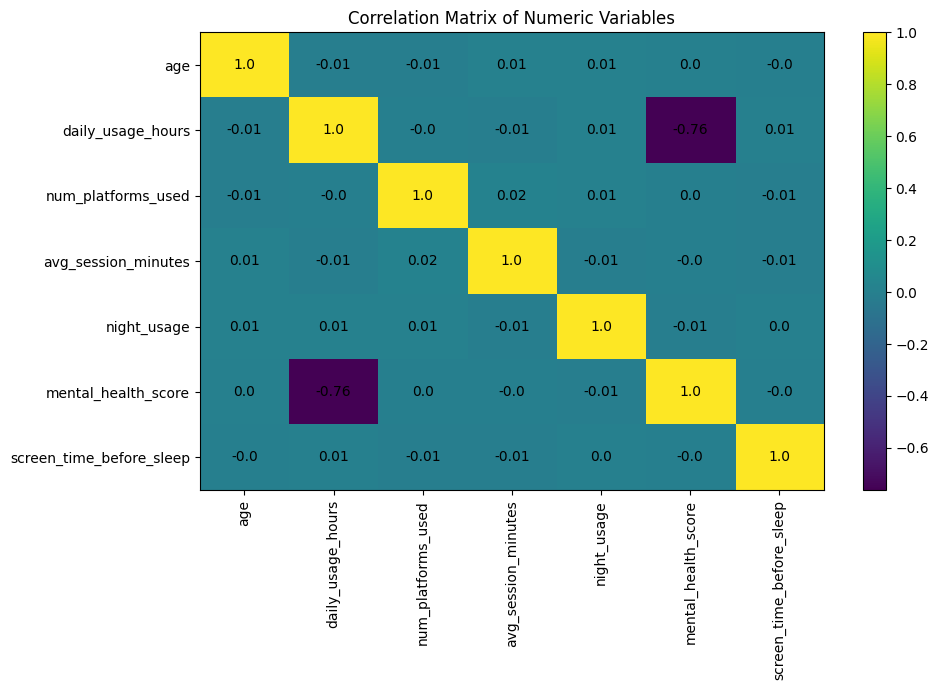

In [23]:
correlation_matrix = df[numeric_cols].corr()

display(correlation_matrix)

plt.figure(figsize=(10,7))
plt.imshow(correlation_matrix, aspect='auto')
plt.colorbar()
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)

for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, round(correlation_matrix.iloc[i, j], 2),
                 ha='center', va='center')

plt.title("Correlation Matrix of Numeric Variables")
plt.tight_layout()
plt.savefig("12_correlation_matrix.png", dpi=300)
plt.show()

Final Summary Table

In [24]:
summary_table = pd.DataFrame({
    "Metric": [
        "Sample Size",
        "Average Age",
        "Average Daily Usage Hours",
        "Median Daily Usage Hours",
        "Average Number of Platforms Used",
        "Average Mental Health Score",
        "Correlation: Daily Usage vs Mental Health"
    ],
    "Value": [
        len(df),
        round(df['age'].mean(), 2),
        round(df['daily_usage_hours'].mean(), 2),
        round(df['daily_usage_hours'].median(), 2),
        round(df['num_platforms_used'].mean(), 2),
        round(df['mental_health_score'].mean(), 2),
        round(corr_usage_mental, 3)
    ]
})

display(summary_table)

summary_table.to_csv("final_summary_table.csv", index=False)

,Metric,Value
0,Sample Size,10000.000
1,Average Age,19.980
2,Average Daily Usage Hours,3.520
3,Median Daily Usage Hours,3.510
4,Average Number of Platforms Used,3.010
5,Average Mental Health Score,7.160
6,Correlation: Daily Usage vs Mental Health,-0.763


Save Final Clean Dataset

In [25]:
df.to_csv("cleaned_genz_social_media_sample_10000.csv", index=False)

print("Analysis complete.")
print("Files created:")
print("1. genz_social_media_sample_10000.csv")
print("2. cleaned_genz_social_media_sample_10000.csv")
print("3. codebook.csv")
print("4. summary_statistics.csv")
print("5. final_summary_table.csv")
print("6. PNG visualizations")

Analysis complete.
Files created:
1. genz_social_media_sample_10000.csv
2. cleaned_genz_social_media_sample_10000.csv
3. codebook.csv
4. summary_statistics.csv
5. final_summary_table.csv
6. PNG visualizations
